# Ejemplo de algoritmo genético
Sacado de un video de youtube: https://www.youtube.com/watch?v=_ZxrvAi0Mk0

Repo donde esta el código del video: https://github.com/danielTeniente/ia-projects/tree/main/Algoritmos_geneticos

## Maximizar una función
El objetivo del algoritmo genético es máximizar o minimizar alguna función, en el caso del video se maximiza una función en concreto

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math

## EL problema
Se debe encontrar el valor de **x** que maximice **y**
 en la siguiente función 

In [2]:
def fx(x):
    return -(0.1+(1-x)**2-0.1*math.cos(6*math.pi*(1-x)))+2

In [3]:
y_axis = []
x_axis=np.arange(0,2,0.02)

for num in x_axis:
    y_axis.append(fx(num))

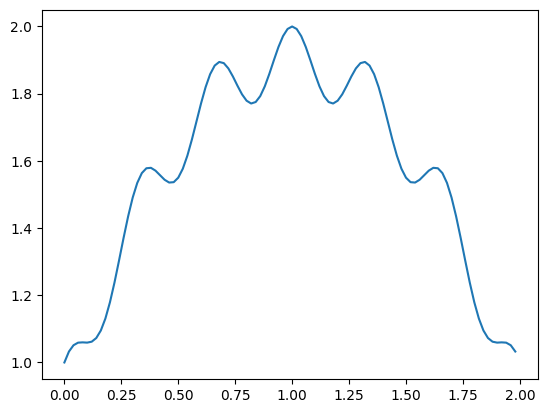

In [4]:
plt.plot(x_axis,y_axis)

Como se puede observar arriba, la función tiene varios máximos y mínimos locales. El objetivo es llegar al punto más alto que se encuentra en x=1

Aquí realicé dos enfoques, uno donde los genes se representan mediante números decimales y otro donde se representan mediante código binario. Esto produce resultados interesantes, pero lo importante es entender los componentes principales del algoritmo genético. Así que avanzaré primero con el enfoque más obvio y luego pasaré al código binario.

## Algoritmos genéticos
### Representación de los genes
Lo primero es planificar que van a representar los genes de nuestros individuos. Los genes (cromosomas/individuos) deben tener la capacidad de resolver el problema, aunque no lo hagan de manera inmediata; y su efectividad debe poder medirse con precisión

In [5]:
# individuo de ejemplo
x = 0.54
y = fx(x)
y

1.615503137257859

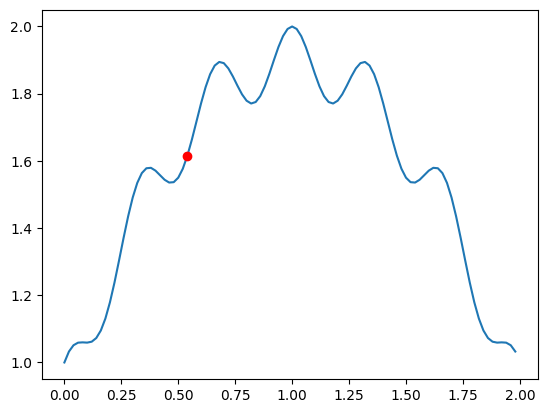

In [6]:
plt.plot(x_axis,y_axis)
plt.plot(x, y, 'ro')

El individuo de ejemplo se encuentra representado en la gráfica anterior. Así que nuestra población debe estar compuesta por números que van desde 0 hasta 2. Sabiendo esto, nuetros genes pueden representar valores decimales de ese número.

In [7]:
# individuo de ejemplo
# x = 0.54
x = [0,5,4] # <-- vector de cromosoma/gen

Hemos representado nuestro gen como una lista para poder realizar la mutación y el cruzamiento. Asi que debemos manejar una función que convierta una lista en números decimales.

In [8]:
def listToDecimal(num):
    decimal = 0
    for i in range(len(num)):
        decimal += num[i]*10**(-i)
    return decimal

In [9]:
listToDecimal(x)

0.54

El tutorial, para hacerlo más interesante, dice que le gustaría manejar individuos con un código genético más grande, así que va a definir un ind_size con el cual generará un primer código genético aleatorio.

In [10]:
ind_size = 15
#Genetic pool
genetic_pool=[[0,1],[0,1,2,3,4,5,6,7,8,9]]

individuo = []
individuo += [np.random.choice(genetic_pool[0])]
individuo += list(np.random.choice(genetic_pool[1],ind_size-1))

individuo

[np.int64(1),
 np.int64(7),
 np.int64(9),
 np.int64(9),
 np.int64(4),
 np.int64(9),
 np.int64(0),
 np.int64(8),
 np.int64(2),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(2),
 np.int64(3),
 np.int64(2)]

In [11]:
listToDecimal(individuo)

np.float64(1.7994908261623201)

Al convertir la lista en decimal podemos notar una pequeña variación al final debido a la forma en que python realiza la suma de punto flotante, pero nada de mucho peso.

In [12]:
poblacion = []

for i in range(100):
    individuo = []
    individuo += [np.random.choice(genetic_pool[0])]
    individuo += list(np.random.choice(genetic_pool[1],ind_size-1))
    poblacion.append(individuo)
poblacion[:5]

[[np.int64(1),
  np.int64(6),
  np.int64(9),
  np.int64(3),
  np.int64(7),
  np.int64(2),
  np.int64(3),
  np.int64(6),
  np.int64(3),
  np.int64(9),
  np.int64(9),
  np.int64(8),
  np.int64(3),
  np.int64(5),
  np.int64(7)],
 [np.int64(1),
  np.int64(6),
  np.int64(8),
  np.int64(2),
  np.int64(3),
  np.int64(9),
  np.int64(3),
  np.int64(0),
  np.int64(9),
  np.int64(8),
  np.int64(8),
  np.int64(8),
  np.int64(5),
  np.int64(8),
  np.int64(4)],
 [np.int64(1),
  np.int64(6),
  np.int64(5),
  np.int64(6),
  np.int64(3),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(1),
  np.int64(4),
  np.int64(5),
  np.int64(4),
  np.int64(1),
  np.int64(1),
  np.int64(4)],
 [np.int64(0),
  np.int64(2),
  np.int64(1),
  np.int64(9),
  np.int64(9),
  np.int64(4),
  np.int64(8),
  np.int64(2),
  np.int64(0),
  np.int64(9),
  np.int64(6),
  np.int64(0),
  np.int64(5),
  np.int64(2),
  np.int64(3)],
 [np.int64(1),
  np.int64(5),
  np.int64(3),
  np.int64(5),
  np.int64(8),
  np.int64(3),
  np.i

Tenemos una población de 100 individuos con genes aleatorios. De esta población inicial vamos a realizar el primer paso: evaluar los individuos según su fitness y seleccionar los mejores individuos para reproducirlos

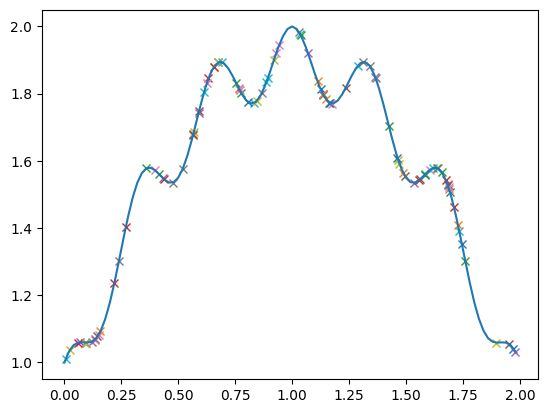

In [13]:
for individuo in poblacion:
    x = listToDecimal(individuo)
    y = fx(x)
    plt.plot(x,y,'x')
plt.plot(x_axis,y_axis)

### Medición del éxito
Esto se suele llamar fitness. Aquí vamos a medir el éxito del individuo para cumplir con el objetivo y determinar la probabilidad que tendrá de reproducirse.
Ya que queremos maximizar una función, aquellos individuos que produzcan un valor más alto en y serán seleccionados como los mejores.

In [14]:
fitness = []

#extraemos valores de y (fitness) para cada individuo
for individuo in poblacion:
    x = listToDecimal(individuo)
    y = fx(x)
    fitness+= [y]
    
#convertimos fitness en un vector para realizar operaciones mas facilmente
fitness = np.array(fitness)
fitness

#divido todos los valores de y para la suma total
#y así obtener valores entre 0 y 1
fitness=fitness/fitness.sum()

In [15]:
fitness

array([0.00950546, 0.00965666, 0.00989241, 0.00781288, 0.00968735,
       0.00679973, 0.00992894, 0.01252169, 0.01186718, 0.00996732,
       0.00657397, 0.01144641, 0.01156526, 0.00973228, 0.00668925,
       0.01118299, 0.01117628, 0.00993989, 0.01004593, 0.01118237,
       0.00984024, 0.00674147, 0.00820965, 0.01136292, 0.011671  ,
       0.00982344, 0.01145873, 0.00822485, 0.00655312, 0.0118847 ,
       0.01134528, 0.00956681, 0.01075711, 0.01164705, 0.0067031 ,
       0.01194843, 0.00683581, 0.01165317, 0.01011635, 0.01247351,
       0.00965052, 0.00689737, 0.00996814, 0.01186089, 0.00977479,
       0.01060342, 0.00960032, 0.01137691, 0.01064449, 0.00637108,
       0.00854622, 0.00987914, 0.00995635, 0.00975552, 0.01211574,
       0.01147246, 0.01227598, 0.01195692, 0.01195138, 0.0119523 ,
       0.01119332, 0.0112519 , 0.01137009, 0.00886351, 0.00668627,
       0.0097573 , 0.01212506, 0.00668492, 0.01199999, 0.01165201,
       0.01016105, 0.01159126, 0.009847  , 0.00974614, 0.00651

Todos los valores de y se dividen entre la suma total para obtener una probabilidad. La operación realizada arriba sirve para representar porcentajes. Por ejemplo, si tengo dos números: [8,5], cuando los divido para la suma obtengo el porcentaje que representan del total:

In [16]:
array = np.array([8,5])
array = array/array.sum()
array

array([0.61538462, 0.38461538])

In [17]:
array = np.array([8,2])
array = array/array.sum()
array

array([0.8, 0.2])

Los números más grandes producen un porcentaje mayor, y ya que la probabilidad se mide entre 0 y 1, esto ya nos permite darle una probabilidad mayor de reproducirse a los mejores individuos, aquellos que obtuvieron números más grandes

### Entrecruzamiento

El entrecruzamiento consiste en mezclar los genes de los mejores individuos. Esn este caso vamos a elegir dos padres al azar, de acuerdo con la probabilidad del fitness para que se produzcan nuevos individuos. Es importante no descartar de lleno los peores individuos ya qye, maybe, su código genético puede servir para lograr algo mejor mas adelante.

Luego, elegimos un *cross_point* a partir del cual se van a combinar los genes de los padres. Se van a copiar los genes del padre hasta este punto, y luego los genes del otro padre,


In [18]:
size_poblacion = len(poblacion)

# hijos
offspring = []
#corremos el bucle 50 veces y en cada iteracion se generán 2 hijos
for i in range(size_poblacion//2):
    # el argumento p=fitness indica que la seleccion de padres se hace en funcion de la probabilidad dada por fitness
    # si no se asigna un p la seleccion es aleatoria uniforme
    parents = np.random.choice(size_poblacion, 2, p=fitness)
    #decidimos el punto de cruce aleatoriamente
    cross_point = np.random.randint(ind_size)
    # generamos los dos hijos y los añadimos a la lista offspring
    offspring += [poblacion[parents[0]][:cross_point] + poblacion[parents[1]][cross_point:]]
    offspring += [poblacion[parents[1]][:cross_point] + poblacion[parents[0]][cross_point:]]

offspring[:10]

[[np.int64(0),
  np.int64(5),
  np.int64(5),
  np.int64(6),
  np.int64(6),
  np.int64(8),
  np.int64(7),
  np.int64(8),
  np.int64(4),
  np.int64(4),
  np.int64(2),
  np.int64(7),
  np.int64(8),
  np.int64(1),
  np.int64(8)],
 [np.int64(1),
  np.int64(1),
  np.int64(3),
  np.int64(3),
  np.int64(5),
  np.int64(1),
  np.int64(5),
  np.int64(8),
  np.int64(4),
  np.int64(6),
  np.int64(2),
  np.int64(5),
  np.int64(9),
  np.int64(7),
  np.int64(6)],
 [np.int64(0),
  np.int64(6),
  np.int64(5),
  np.int64(6),
  np.int64(5),
  np.int64(2),
  np.int64(8),
  np.int64(7),
  np.int64(8),
  np.int64(3),
  np.int64(9),
  np.int64(0),
  np.int64(6),
  np.int64(0),
  np.int64(9)],
 [np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(8),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(7),
  np.int64(9),
  np.int64(8),
  np.int64(6),
  np.int64(8),
  np.int64(5),
  np.int64(9)],
 [np.int64(1),
  np.int64(4),
  np.int64(6),
  np.int64(5),
  np.int64(9),
  np.int64(4),
  np.i

La función np.random.choice por defecto tiene un parámetro llamado replace=True (reemplazo). Esto significa que cuando saca una bola del saco (elige un padre), "la vuelve a meter" antes de sacar la siguiente.
- En la misma pareja: Podría salir el mismo individuo dos veces (Padre A con Padre A). En ese caso, el "cruce" generaría clones de sí mismo.
- En distintas parejas: Un individuo muy bueno puede ser padre en la pareja 1, en la pareja 5 y en la 20.

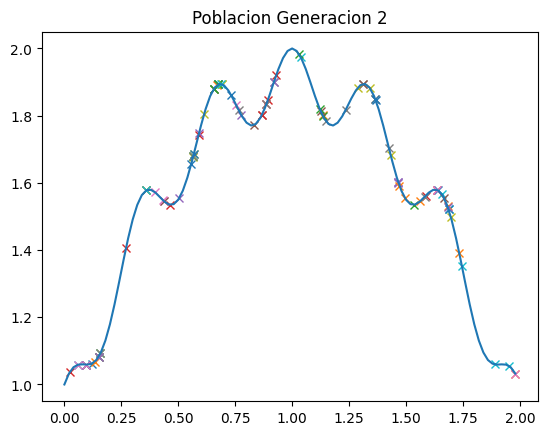

In [19]:
# actualizamos la poblacion con los nuevos hijos
poblacion = offspring
for individuo in poblacion:
    x = listToDecimal(individuo)
    y = fx(x)
    plt.plot(x,y,'x')
#añade titulo de poblacion generacion 2
plt.title("Poblacion Generacion 2")
plt.plot(x_axis,y_axis)

En una sola generación podemos ver que los individuos ya se están concentrando en puntos más altos de la función. A medida que pasen las generaciones el objetivo es que todos los individuos convergan alrededor de 1.

### Mutación
Otro aspecto interesante del algoritmo genético es la probabilidad de que se produzca una mutación en los individuos. Lo que significa que el ADN de cualquier individuo puede producir un gen que no viene de sus padres.
El individuo [0,5,3,8,9] puede mutar a [0,5,4,8,9] y esto mantiene la puerta abierta hacia el mejoramiento de la población.

In [20]:
def mutate(individuals, prob, pool):
    # El algoritmo va individuo por individuo. Nadie se salva de la posibilidad de mutar.
    for i in range(len(individuals)):
        mutate_individual=individuals[i]
        if np.random.random() < prob:
            mutation = np.random.choice(pool[0])
            mutate_individual = [mutation] + mutate_individual[1:]
        
        for j in range(1,len(mutate_individual)):
            if np.random.random() < prob:
                mutation = np.random.choice(pool[1])
                mutate_individual = mutate_individual[0:j] + [mutation] + mutate_individual[j+1:]
        individuals[i] = mutate_individual

In [21]:
mutate(
    individuals=poblacion,
    prob=0.005,
    pool=genetic_pool
    )

poblacion[:10]

[[np.int64(0),
  np.int64(5),
  np.int64(5),
  np.int64(6),
  np.int64(6),
  np.int64(8),
  np.int64(7),
  np.int64(8),
  np.int64(4),
  np.int64(4),
  np.int64(2),
  np.int64(7),
  np.int64(8),
  np.int64(1),
  np.int64(8)],
 [np.int64(1),
  np.int64(1),
  np.int64(3),
  np.int64(3),
  np.int64(5),
  np.int64(1),
  np.int64(5),
  np.int64(8),
  np.int64(4),
  np.int64(6),
  np.int64(2),
  np.int64(5),
  np.int64(9),
  np.int64(7),
  np.int64(6)],
 [np.int64(0),
  np.int64(6),
  np.int64(5),
  np.int64(6),
  np.int64(5),
  np.int64(2),
  np.int64(8),
  np.int64(7),
  np.int64(8),
  np.int64(3),
  np.int64(9),
  np.int64(0),
  np.int64(6),
  np.int64(0),
  np.int64(9)],
 [np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(8),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(7),
  np.int64(9),
  np.int64(8),
  np.int64(6),
  np.int64(8),
  np.int64(5),
  np.int64(9)],
 [np.int64(1),
  np.int64(4),
  np.int64(6),
  np.int64(5),
  np.int64(9),
  np.int64(4),
  np.i

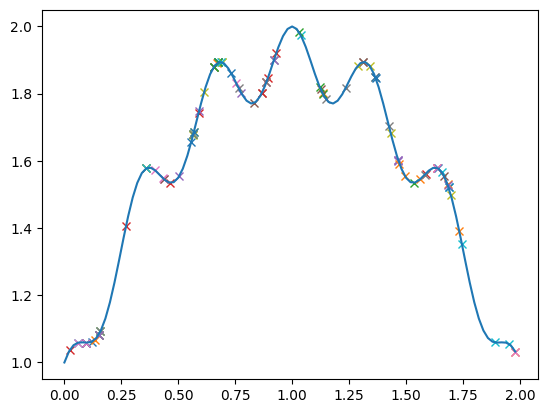

In [22]:
for individuo in poblacion:
    x = listToDecimal(individuo)
    y = fx(x)
    plt.plot(x,y,'x')
plt.plot(x_axis,y_axis)

### Resultado final
Vamos a compactar el código del algoritmo. Ya hemos visto los pasos que sigue en una generación. Hay que extender esto al número de generaciones que consideremos optimo

In [23]:
generaciones = 100

for _ in range(generaciones):
    
    fitness = []
    
    #extraemos valores de y (fitness) para cada individuo
    for individuo in poblacion:
        x = listToDecimal(individuo)
        y = fx(x)
        fitness+= [y]
        
    #convertimos fitness en un vector para realizar operaciones mas facilmente
    fitness = np.array(fitness)
    
    #divido todos los valores de y para la suma total
    #y así obtener valores entre 0 y 1
    fitness=fitness/fitness.sum()
    
    #se reproducen los mejores individuos
    offspring = []
    for i in range(size_poblacion//2):
        # el argumento p=fitness indica que la seleccion de padres se hace en funcion de la probabilidad dada por fitness
        # si no se asigna un p la seleccion es aleatoria uniforme
        parents = np.random.choice(size_poblacion, 2, p=fitness)
        #decidimos el punto de cruce aleatoriamente
        cross_point = np.random.randint(ind_size)
        # generamos los dos hijos y los añadimos a la lista offspring
        offspring += [poblacion[parents[0]][:cross_point] + poblacion[parents[1]][cross_point:]]
        offspring += [poblacion[parents[1]][:cross_point] + poblacion[parents[0]][cross_point:]]
        
    poblacion = offspring
    
    ## MUTACIONES ##
    
    mutate(
        individuals=poblacion,
        prob=0.005,
        pool=genetic_pool
        )
    

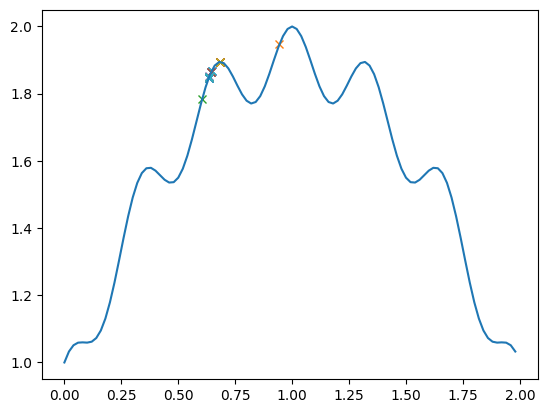

In [24]:
for individuo in poblacion:
    x = listToDecimal(individuo)
    y = fx(x)
    plt.plot(x,y,'x')
plt.plot(x_axis,y_axis)

Después de 100 generaciones podemos ver que la mayoría de los individuos se concentran en el valor máximo. Y si vemos el mejor individuo vamos a ver que su valor es cercano a 1.

In [25]:
np.where(fitness == fitness.max())

(array([53]),)

In [26]:
listToDecimal(poblacion[50])

np.float64(0.6348784990494502)

In [27]:

fx(listToDecimal(poblacion[50]))

np.float64(1.8492653996486008)

Podríamos dejarlos reproducirse por unas cuántas generaciones más a ver si siguen avanzando hacia el máximo.

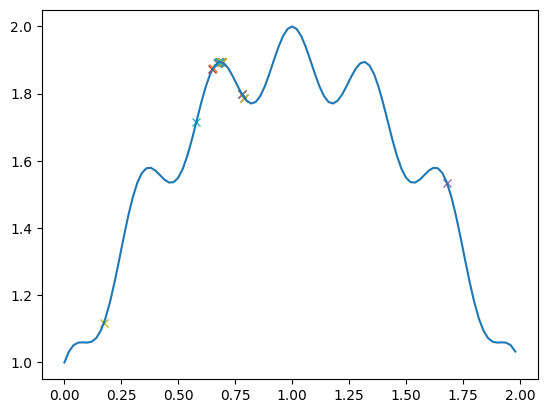

In [28]:
generaciones = 300

for _ in range(generaciones):
    
    fitness =[]

    #extraigo los valores de y para medir su éxito
    for individuo in poblacion:
        x = listToDecimal(individuo)
        y = fx(x)
        fitness += [y]

    #convierto fitnees en un vector para realizar operaciones
    #más fácilmente
    fitness = np.array(fitness)

    #divido todos los valores de y para la suma total
    #y así obtener valores entre 0 y 1
    fitness=fitness/fitness.sum()    
        
    
    # se reproducen los mejores individuos
    offspring = []
    for i in range(size_poblacion//2):
        parents = np.random.choice(size_poblacion, 2, p=fitness)
        cross_point = np.random.randint(ind_size)
        offspring += [poblacion[parents[0]][:cross_point] + poblacion[parents[1]][cross_point:]]
        offspring += [poblacion[parents[1]][:cross_point] + poblacion[parents[0]][cross_point:]]    
    
    poblacion = offspring
    
    #####
    # MUTACIONES
    ####
     
    mutate(poblacion,0.005,genetic_pool)
    
for individuo in poblacion:
    x = listToDecimal(individuo)
    y = fx(x)
    plt.plot(x,y,'x')
plt.plot(x_axis,y_axis)

## Indviduos con ADN binario
Si hacemos que el ADN no represente números binarios, sino una división, entonces el individuo será mucho más estable. Como ya expliqué lo importante del algoritmo genético, no voy a detenerme mucho con este enfoque.

In [39]:
def bin_decimal(num_binario):
    return (np.sum(num_binario)/len(num_binario))*2

Esta función transforma una lista de numeros binarios en un número que va del 0 al 2. Su funcionamiento es el siguiente: suma todos los 1 del ADN y luego los divide para la longitud del ADN. Es muy similar al cálculo del fitness, Esto devuelve un numero entre 0 y 1, si este número se multiplica por 2, ahora tenemos una forma de producir números entre 0 y 2.

In [40]:
#resultado de sumar todos los 1
individuo = [0,1,1,1,1,0]
bin_decimal(individuo)

np.float64(1.3333333333333333)

In [41]:
4/6 * 2

1.3333333333333333

HAcemos lo mismo que antes:

In [51]:
poblacion = []
genetic_pool = [0,1]
for i in range(100):
    individuo = list(np.random.choice(genetic_pool,15))
    poblacion.append(individuo)
poblacion[:1]

[[np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(0)]]

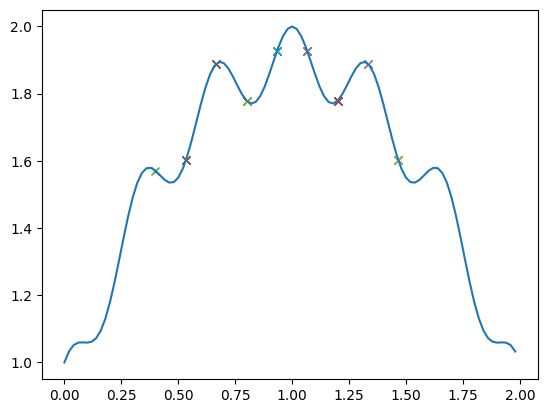

In [64]:
for individuo in poblacion:
    x = bin_decimal(individuo)
    y = fx(x)
    plt.plot(x,y,'x')
plt.plot(x_axis,y_axis)

In [44]:
def mutate_binary(individuals, prob, pool):
    for i in range(len(individuals)):
        mutate_individual = individuals[i]
        
        for j in range(len(mutate_individual)):
            if np.random.random() < prob:
                # LÓGICA DE INVERSIÓN (FLIP)
                # Obtenemos el valor actual
                gen_actual = mutate_individual[j]
                
                # Calculamos el contrario matemático
                mutation = 1 - gen_actual 
                
                # Aplicamos el cambio usando slicing (igual que antes)
                mutate_individual = mutate_individual[0:j] + [mutation] + mutate_individual[j+1:]
        
        individuals[i] = mutate_individual

In [45]:
generaciones = 300

for _ in range(generaciones):
    
    fitness = []
    
    #extraemos valores de y (fitness) para cada individuo
    for individuo in poblacion:
        x = bin_decimal(individuo)
        y = fx(x)
        fitness+= [y]
        
    #convertimos fitness en un vector para realizar operaciones mas facilmente
    fitness = np.array(fitness)
    
    #divido todos los valores de y para la suma total
    #y así obtener valores entre 0 y 1
    fitness=fitness/fitness.sum()
    
    #se reproducen los mejores individuos
    offspring = []
    for i in range(size_poblacion//2):
        # el argumento p=fitness indica que la seleccion de padres se hace en funcion de la probabilidad dada por fitness
        # si no se asigna un p la seleccion es aleatoria uniforme
        parents = np.random.choice(size_poblacion, 2, p=fitness)
        #decidimos el punto de cruce aleatoriamente
        cross_point = np.random.randint(ind_size)
        # generamos los dos hijos y los añadimos a la lista offspring
        offspring += [poblacion[parents[0]][:cross_point] + poblacion[parents[1]][cross_point:]]
        offspring += [poblacion[parents[1]][:cross_point] + poblacion[parents[0]][cross_point:]]
        
    poblacion = offspring
    
    ## MUTACIONES ##
    
    mutate_binary(
        individuals=poblacion,
        prob=0.005,
        pool=genetic_pool
        )
    

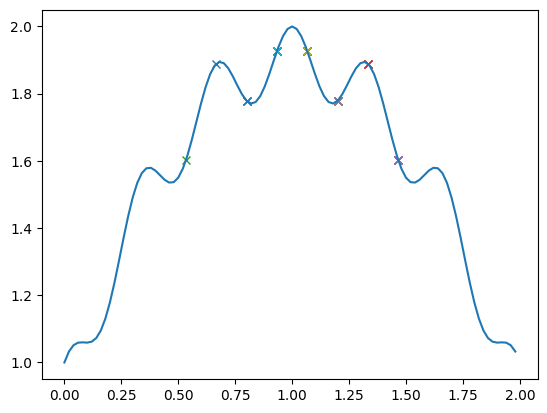

In [46]:
for individuo in poblacion:
    x = bin_decimal(individuo)
    y = fx(x)
    plt.plot(x,y,'x')
plt.plot(x_axis,y_axis)